In [ ]:
import sys, os
sys.path.append(os.path.abspath('..'))
from src.config import *
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# HuggingFace Token
HF_TOKEN = "hf_xxxxxxxxxxxxxxxxxxxxxxxx" 

In [2]:
dataset = load_dataset(
    "google/civil_comments",
    split="train",
    streaming=True,
    token=HF_TOKEN
)

sample = []
for i, row in enumerate(dataset):
    sample.append(row)
    if i >= 9999:
        break

df = pd.DataFrame(sample)
print(f"Loaded {len(df):,} comments")
df.head(3)

Loaded 10,000 comments


,text,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,sexual_explicit
0,"This is so cool. It's like, 'would you want yo...",0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Thank you!! This would make my life a lot less...,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,This is such an urgent design problem; kudos t...,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Plot saved to: d:\Workbook\Civil Comments Project\outputs\figures\01_toxicity_distribution.png


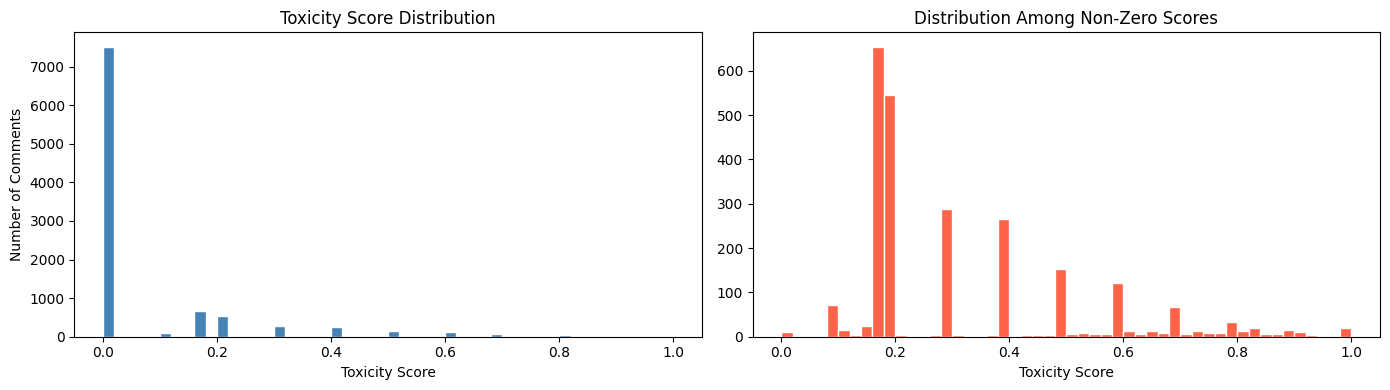


Toxic comments (>0.5): 427 / 10,000
That's 4.3% of comments


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full distribution
axes[0].hist(df['toxicity'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Toxicity Score Distribution')
axes[0].set_xlabel('Toxicity Score')
axes[0].set_ylabel('Number of Comments')

# Right: non-zero scores only
toxic = df[df['toxicity'] > 0.0]
axes[1].hist(toxic['toxicity'], bins=50, color='tomato', edgecolor='white')
axes[1].set_title('Distribution Among Non-Zero Scores')
axes[1].set_xlabel('Toxicity Score')

plt.tight_layout()

# Save
save_path = os.path.join(FIGURES_DIR, '01_toxicity_distribution.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Plot saved to: {save_path}")

plt.show()

print(f"\nToxic comments (>0.5): {(df['toxicity'] > 0.5).sum():,} / {len(df):,}")
print(f"That's {(df['toxicity'] > 0.5).mean()*100:.1f}% of comments")

In [4]:
score_cols = ['toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack']
summary = df[score_cols].describe().round(3)
print(summary)

# Save summary table
summary_path = os.path.join(DATA_DIR, '01_score_summary.csv')
summary.to_csv(summary_path)
print(f"\nSummary table saved to: {summary_path}")

        toxicity  severe_toxicity    obscene     threat     insult  \
count  10000.000        10000.000  10000.000  10000.000  10000.000   
mean       0.082            0.004      0.015      0.008      0.063   
std        0.176            0.021      0.074      0.041      0.153   
min        0.000            0.000      0.000      0.000      0.000   
25%        0.000            0.000      0.000      0.000      0.000   
50%        0.000            0.000      0.000      0.000      0.000   
75%        0.000            0.000      0.000      0.000      0.000   
max        1.000            0.300      1.000      0.719      1.000   

       identity_attack  
count        10000.000  
mean             0.016  
std              0.065  
min              0.000  
25%              0.000  
50%              0.000  
75%              0.000  
max              0.833  

Summary table saved to: d:\Workbook\Civil Comments Project\data\01_score_summary.csv
